# Load Dataset

In [1]:
import numpy as np 
import pandas as pd

import seaborn as sns 
import matplotlib.pyplot as plt  

In [2]:
import easydict 

args = easydict.EasyDict()

args.train_file = "./data/train.csv"
args.test_file = "./data/test.csv"
args.submission_file = "./data/submission.csv"

In [3]:
train = pd.read_csv(args.train_file)
train.shape # (row, columns=features+target)

(916, 12)

In [4]:
test = pd.read_csv(args.test_file)
test.shape # (row, columns=features)

(393, 11)

In [5]:
submission = pd.read_csv(args.submission_file)
submission.shape # (row, columns=ID+target)

(393, 2)

## Target

In [6]:
# 각 class간의 비율 확인 
train['survived'].value_counts() / train.shape[0]

survived
0    0.622271
1    0.377729
Name: count, dtype: float64

# EDA

In [7]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 916 entries, 0 to 915
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   passengerid  916 non-null    int64  
 1   survived     916 non-null    int64  
 2   pclass       916 non-null    int64  
 3   name         916 non-null    str    
 4   gender       916 non-null    str    
 5   age          736 non-null    float64
 6   sibsp        916 non-null    int64  
 7   parch        916 non-null    int64  
 8   ticket       916 non-null    str    
 9   fare         916 non-null    float64
 10  cabin        198 non-null    str    
 11  embarked     915 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 86.0 KB


# Data Preprocessing

## data cleaning

In [8]:
# row 중복 제거 
print(f"before: {train.shape}")

# 평가는 학습을 하는 데이터가 아니기 때문에 row 중복 제거 제외
train.drop_duplicates(inplace=True)
print(f"after: {train.shape}")

before: (916, 12)
after: (916, 12)


In [9]:
# 결측치 확인 및 제거 
null_tr = train.isnull().sum()

(null_tr[null_tr > 0] / train.shape[0]).sort_values(ascending=False)

cabin       0.783843
age         0.196507
embarked    0.001092
dtype: float64

In [10]:
print(f"before: {train.isnull().sum().sum()} / {test.isnull().sum().sum()}")

for tmp in [train, test]:
    null_tmp = tmp.isnull().sum()
    null_cols = null_tmp[null_tmp > 0].index

    for col in null_cols:
        try:
            tmp[col] = tmp[col].fillna(train[col].mean())

        except:
            tmp[col] = tmp[col].fillna(train[col].mode().values[0])

print(f"after: {train.isnull().sum().sum()} / {test.isnull().sum().sum()}")

before: 899 / 381
after: 0 / 0


In [11]:
train.columns 

Index(['passengerid', 'survived', 'pclass', 'name', 'gender', 'age', 'sibsp',
       'parch', 'ticket', 'fare', 'cabin', 'embarked'],
      dtype='str')

In [12]:
train.set_index(['passengerid'], inplace=True)
test.set_index(['passengerid'], inplace=True)
train.head()

,survived,pclass,name,gender,age,sibsp,parch,ticket,fare,cabin,embarked
passengerid,,,,,,,,,,,
0,0,2,"Wheeler, Mr. Edwin Frederick""""",male,29.69837,0,0,SC/PARIS 2159,12.8750,B57 B59 B63 B66,S
1,0,3,"Henry, Miss. Delia",female,29.69837,0,0,382649,7.7500,B57 B59 B63 B66,Q
2,1,1,"Hays, Mrs. Charles Melville (Clara Jennings Gr...",female,52.00000,1,1,12749,93.5000,B69,S
3,1,3,"Andersson, Mr. August Edvard (""Wennerstrom"")",male,27.00000,0,0,350043,7.7958,B57 B59 B63 B66,S
4,0,2,"Hold, Mr. Stephen",male,44.00000,1,0,26707,26.0000,B57 B59 B63 B66,S


In [13]:
train.columns 

Index(['survived', 'pclass', 'name', 'gender', 'age', 'sibsp', 'parch',
       'ticket', 'fare', 'cabin', 'embarked'],
      dtype='str')

In [14]:
ticket_counts = pd.concat([train['ticket'], test['ticket']]).value_counts()

train['ticket_group_size'] = train['ticket'].map(ticket_counts)
test['ticket_group_size'] = test['ticket'].map(ticket_counts)

In [15]:
import re
TITLE_MAP = {
    'Mlle': 'Miss', 'Ms': 'Miss', 'Mme': 'Mrs', 'Col': 'Military', 'Major': 'Military', 'Capt': 'Military',
    'Don': 'Noble', 'Dona': 'Noble', 'Sir': 'Noble', 'Lady': 'Noble', 
    'Jonkheer': 'Noble', 'the Countess': 'Noble',
}

def extract_title(name):
    m = re.search(r',\s*([^\.]*)\.', name)
    raw = m.group(1).strip() if m else 'Unknown'
    return TITLE_MAP.get(raw, raw)

for df in (train, test):
    df['title'] = df['name'].apply(extract_title)


In [16]:
cat_cols = ['pclass', 'gender', 'title']

In [17]:
train.drop(['name', 'ticket', 'cabin', 'embarked'], axis=1, inplace=True)
test.drop(['name', 'ticket', 'cabin', 'embarked'], axis=1, inplace=True)

In [18]:
cat_cols = [
    'pclass', 'gender', 'title'
]

# Modeling

In [19]:
from common.modeling import Modeling

## Check Dataset before Modeling

In [20]:
modeling = Modeling(
    x_tr=train.drop(['survived'], axis=1),
    y_tr=train['survived'],
    cat_cols=cat_cols
)

In [21]:
modeling.fit_evaluation(
    x_te = train.drop(['survived'], axis=1),
    y_te = train['survived']
)

training..:   0%|          | 0/3 [00:00<?, ?it/s]

In [22]:
modeling.get_best_model()

{'model': XGBClassifier(base_score=None, booster=None, callbacks=None,
               colsample_bylevel=None, colsample_bynode=None,
               colsample_bytree=None, device=None, early_stopping_rounds=None,
               enable_categorical=True, eval_metric=None, feature_types=None,
               feature_weights=None, gamma=None, grow_policy=None,
               importance_type=None, interaction_constraints=None,
               learning_rate=None, max_bin=None, max_cat_threshold=None,
               max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
               max_leaves=None, min_child_weight=None, missing=nan,
               monotone_constraints=None, multi_strategy=None, n_estimators=None,
               n_jobs=None, num_parallel_tree=None, ...),
 'model_name': 'XGBClassifier',
 'hpo': {'tree_method': 'hist', 'enable_categorical': True},
 'train_score': 0.9591775681979515,
 'test_score': 0.9591775681979515,
 'score_type': 'get_auc_score'}

# Evaluation

In [23]:
print(
    f'훈련용 평가지표: {modeling.get_best_model()['train_score']} / 테스트용 평가지표: {modeling.get_best_model()['test_score']}'
)

훈련용 평가지표: 0.9591775681979515 / 테스트용 평가지표: 0.9591775681979515


In [24]:
bool_cols = train.select_dtypes(include=["bool", "boolean"]).columns
train[bool_cols] = train[bool_cols].astype("int8")

train[cat_cols] = train[cat_cols].astype('category')

## Bayesian Optimization (Optuna)

강의안 `5. HPO.ipynb`의 Bayesian Search 방식을 그대로 따라간다: `train_test_split`으로 진짜 홀드아웃(`X_te`)을 먼저 떼어두고, Optuna의 `TPESampler`가 이전 시도 결과를 참고해서 다음 하이퍼파라미터 조합을 제안하는 방식(Bayesian Optimization)으로 탐색한다.

모델은 CatBoost 대신 **LightGBM**을 쓴다 — 이유는 두 가지: 1) `cat_cols`가 이미 `category` dtype으로 되어 있어서 LightGBM이 별도 설정 없이 자동으로 범주형을 인식하고, 2) 탐색을 30번 반복해야 하는데 CatBoost는 한 번 학습에도 시간이 오래 걸려서(체감상 몇 분) 전체 탐색이 너무 오래 걸림. LightGBM은 훨씬 빠름.

In [25]:
# 터미널에서 먼저 설치: uv add optuna
import optuna
from optuna.samplers import TPESampler
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import roc_auc_score
from lightgbm import LGBMClassifier

optuna.logging.disable_default_handler()

In [26]:
# 강사님 버전 스플릿: 진짜 홀드아웃 20%를 따로 떼어둠
random_state = 42

X_tr, X_te, y_tr, y_te = train_test_split(
    train.drop(['survived'], axis=1), train['survived'],
    test_size=0.20, shuffle=True, random_state=random_state
)

X_tr.shape, X_te.shape

((732, 8), (184, 8))

#### 목적 함수

In [27]:
class Objective:
    def __init__(self, x_train, y_train, seed):
        self.x_train = x_train
        self.y_train = y_train
        self.seed = seed
        num_folds = 5
        self.cv = StratifiedKFold(n_splits=num_folds, shuffle=True, random_state=self.seed)

    def __call__(self, trial):
        hp = {
            "max_depth": trial.suggest_int("max_depth", 3, 10),
            "n_estimators": trial.suggest_int("n_estimators", 100, 500, step=50),
            "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
            "num_leaves": trial.suggest_int("num_leaves", 15, 63),
            "min_child_samples": trial.suggest_int("min_child_samples", 5, 30),
            "reg_alpha": trial.suggest_float("reg_alpha", 0.0, 5.0),
            "reg_lambda": trial.suggest_float("reg_lambda", 0.0, 5.0),
            "verbosity": -1,
        }
        # model
        model = LGBMClassifier(random_state=self.seed, n_jobs=1, **hp)
        # cross validation (X_tr 안에서 또 5-fold)
        scores = cross_val_score(model, self.x_train, self.y_train, cv=self.cv, scoring="roc_auc")
        return np.mean(scores)

#### 학습

In [28]:
sampler = TPESampler(seed=random_state)  # 대체모델 부분

study = optuna.create_study(
    direction="maximize",
    sampler=sampler
)
objective = Objective(X_tr, y_tr, random_state)
study.optimize(objective, n_trials=30)

print("Best Score:", study.best_value)   # 최고점수
print("Best hp:", study.best_params)      # 최고점수의 하이퍼파라미터조합

Best Score: 0.9091231904741222
Best hp: {'max_depth': 8, 'n_estimators': 100, 'learning_rate': 0.0859722884011492, 'num_leaves': 19, 'min_child_samples': 10, 'reg_alpha': 4.762876115778549, 'reg_lambda': 4.4754625780873525}


In [29]:
# X_te(진짜 홀드아웃)로 최종 확인 -> 이 숫자가 리포트에 적을 test score
best_model = LGBMClassifier(random_state=random_state, n_jobs=1, **study.best_params)
best_model.fit(X_tr, y_tr)

pred = best_model.predict_proba(X_te)[:, 1]
roc_auc_score(y_te, pred)

0.8795112781954886

하이퍼파라미터 중요도

In [30]:
optuna.visualization.plot_param_importances(study)

탐색 과정 그래프

In [31]:
optuna.visualization.plot_optimization_history(study)

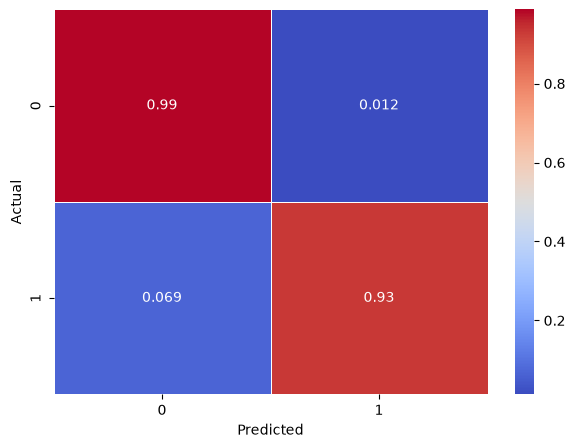

In [32]:
from common.evaluation_plots import show_norm_conf_mx

pred = modeling.predict_by_best_model(train.drop(['survived'], axis=1))

show_norm_conf_mx(y=train['survived'], pred=pred)

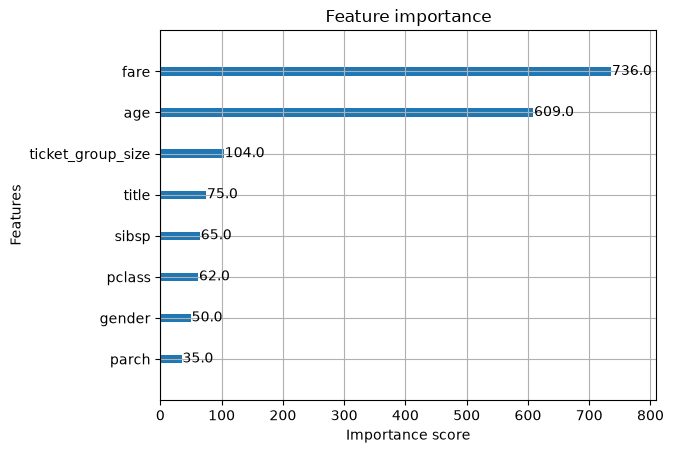

In [33]:
from common.modeling import BoostModelType

BoostModelType.show_plot_importance(modeling.get_best_model()['model'])

# Submission

In [34]:
bool_cols = test.select_dtypes(include=["bool", "boolean"]).columns
test[bool_cols] = test[bool_cols].astype("int8")

test[cat_cols] = test[cat_cols].astype('category')


## Bayesian 최적화 결과로 제출

위에서 찾은 `study.best_params`로, 이번엔 홀드아웃(`X_tr`)이 아니라 **전체 `train`**으로 다시 학습해서 제출한다.

In [35]:
final_model = LGBMClassifier(random_state=random_state, n_jobs=1, **study.best_params)
final_model.fit(train.drop(['survived'], axis=1), train['survived'])

pred_bayes = final_model.predict(test)

In [36]:
submission['survived'] = pred_bayes
submission.head()

,passengerid,survived
0,916,1
1,917,1
2,918,1
3,919,0
4,920,1


In [37]:
submission.to_csv("./submission/base_model_bayesian_0910.csv", index=False)

### 확률 기반 제출 (하드 0/1 대신)

4번 파일과 같은 이유 — 위 제출은 `predict()`로 하드 0/1이라 AUC 기준으로는 정보 손실이 있음. 같은 `final_model`로 확률(`predict_proba`)을 뽑아서 다시 제출.

In [ ]:
pred_bayes_proba = final_model.predict_proba(test)[:, 1]

In [ ]:
submission['survived'] = pred_bayes_proba
submission.head()

In [ ]:
submission.to_csv("./submission/base_model_bayesian_proba_0910.csv", index=False)

In [38]:
pred = modeling.predict_by_best_model(test)

In [39]:
submission.shape , len(pred)

((393, 2), 393)

In [40]:
submission['survived'] = pred

submission.head()

,passengerid,survived
0,916,1
1,917,1
2,918,1
3,919,0
4,920,1


In [41]:
submission.to_csv("./submission/base_model_0909_01_(9591).csv", index=False)